# Задача регрессии (self implementation)

In [1]:
# Импортируем необходимые библиотеки
import numpy as np  # для численных вычислений
import pandas as pd  # для работы с табличными данными
from sklearn.model_selection import train_test_split  # для разделения данных на обучающую и тестовую выборку
import matplotlib.pyplot as plt  # для визуализации
from sklearn.linear_model import LinearRegression as LR  # готовый алгоритм линейной регрессии
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # для оценки качества обучения модели

In [2]:
# Создадим класс линейной регрессии,
# который будет содержать ключевые методы для решения задачи:
# - конструктор класса;
# - метод обучения алгоритма;
# - метод пересчета весов;
# - метод, делающий предсказания на основе найденного уравнения.
# ----------------------------------------------------------------
# Цель линейной регрессии — поиск линии, которая наилучшим образом
# соответствует этим точкам.
class LinearRegression:
    """
    Класс реализует модель линейной регрессии,
    обучаемую методом градиентного спуска.

    Модель имеет вид:
        y = Xw + b

    где:
        w — вектор весов,
        b — смещение (bias).
    """

    def __init__(self, learning_rate: float = 0.01, iterations: int = 1000):
        """
        Используется для инициализации параметров класса.

        :param learning_rate: скорость обучения (шаг градиентного спуска).
        :param iterations: количество итераций обучения модели.
        """
        self.learning_rate = float(learning_rate)
        self.iterations = int(iterations)

        # Параметры модели
        self.weights: np.ndarray | None = None
        self.bias: float = 0.0

        # Данные, используемые в процессе обучения
        self.X: np.ndarray | None = None
        self.Y: np.ndarray | None = None

        # История значения функции потерь
        self.loss_history: list[float] = []

    def fit(self, X, Y):
        """
        Метод обучает модель линейной регрессии.

        Задача — на основе входных данных X и целевой переменной Y
        найти оптимальные веса и смещение, минимизируя функцию потерь (MSE).

        Алгоритм:
            1. Инициализация весов и смещения.
            2. Повторение заданного числа итераций:
                - вычисление предсказаний,
                - вычисление ошибки,
                - обновление параметров методом градиентного спуска.

        :param X: матрица признаков формы (m, n),
                  где m — количество объектов,
                  n — количество признаков.
        :param Y: вектор целевых значений формы (m,).
        :return: обученный объект модели.
        """
        X = np.asarray(X, dtype=float)
        Y = np.asarray(Y, dtype=float).reshape(-1)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        m, n = X.shape

        # Инициализация параметров
        self.weights = np.zeros(n)
        self.bias = 0.0

        self.X = X
        self.Y = Y

        for _ in range(self.iterations):
            self.update_weights()

            # Сохраняем значение ошибки (MSE)
            predictions = self.predict(X)
            loss = np.mean((Y - predictions) ** 2)
            self.loss_history.append(loss)

        return self

    def update_weights(self):
        """
        Выполняет один шаг градиентного спуска.

        Вычисляет:
            - градиент функции потерь по весам,
            - градиент по смещению,

        Затем обновляет параметры модели.

        Формулы для MSE:

            dW = (-2/m) * X^T (Y - Y_pred)
            db = (-2/m) * sum(Y - Y_pred)

        где:
            m — количество объектов.
        """
        if self.X is None or self.Y is None or self.weights is None:
            raise ValueError("Модель не обучена. Сначала вызовите fit().")

        X = self.X
        Y = self.Y
        m = X.shape[0]

        predictions = X @ self.weights + self.bias
        error = Y - predictions

        dW = (-2.0 / m) * (X.T @ error)
        db = (-2.0 / m) * np.sum(error)

        self.weights -= self.learning_rate * dW
        self.bias -= self.learning_rate * db

        return self.weights, self.bias

    def predict(self, X):
        """
        Используется для предсказания значений на основе обученной модели.

        Применяет формулу линейной регрессии:
            y = Xw + b

        :param X: матрица признаков формы (m, n)
                  или вектор формы (m,)
        :return: вектор предсказанных значений формы (m,)
        """
        if self.weights is None:
            raise ValueError("Модель не обучена. Сначала вызовите fit().")

        X = np.asarray(X, dtype=float)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        return X @ self.weights + self.bias

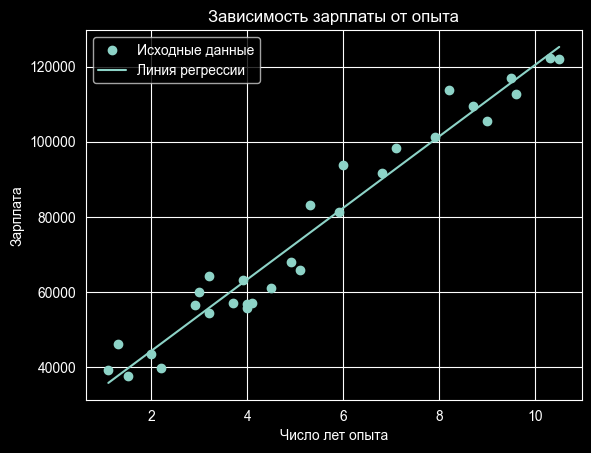

In [3]:
# Пример кода со считыванием и подготовкой данных для обучения,
# а также использование класса линейной регрессии для обучения.
df = pd.read_csv("input_data/salary_data.csv")

X = df.iloc[:, :-1].values  # признаки
Y = df.iloc[:, 1].values  # цель

model = LinearRegression(iterations=1000, learning_rate=0.01)
model.fit(X, Y)

Y_pred = model.predict(X)

plt.scatter(X, Y, label="Исходные данные")
plt.plot(X, Y_pred, label="Линия регрессии")
plt.title("Зависимость зарплаты от опыта")
plt.xlabel("Число лет опыта")
plt.ylabel("Зарплата")
plt.legend()
plt.show()

📊1️⃣График "Зависимость зарплаты от опыта"

Что мы видим:
- Голубые точки — реальные данные.
- Линия — предсказания модели.
- Линия хорошо проходит через центр облака точек.

Интерпретация:
1. Наблюдается четкая линейная зависимость:
- зарплата растет примерно линейно с увеличением опыта.
2. Линия регрессии:
- не слишком крутая
- не слишком плоская
- проходит примерно посередине точек

Это означает:
1. Модель хорошо уловила общий тренд.

Что можно сказать про качество:
1. Нет явной недообученности (линия не "мимо" данных)
2. Нет переобучения (линия не повторяет шум)
3. Ошибки выглядят примерно равномерными
4. Визуально — хорошая аппроксимация.

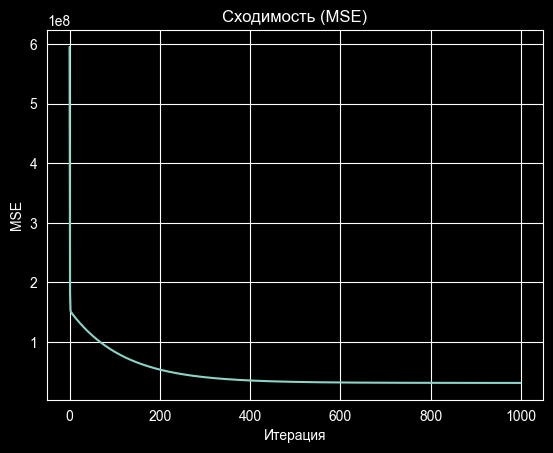

In [4]:
# График сходимости
plt.plot(model.loss_history)
plt.title("Сходимость (MSE)")
plt.xlabel("Итерация")
plt.ylabel("MSE")
plt.show()

📉2️⃣График "Сходимость (MSE)"

Это самый интересный график с точки зрения ML.

Что происходит:
1. В начале ошибка огромная (~6e8)
2. Затем она резко падает
3. Потом снижение замедляется
4. В конце кривая выходит на плато

🔎 Что это значит

🔹 Резкое падение в начале
Модель быстро находит направление правильного минимума.
Это нормальное поведение градиентного спуска.

🔹 Плавное замедление
Когда мы приближаемся к минимуму, градиенты становятся меньше.
Шаги становятся «тонкими».

🔹 Плато
Это означает:
Модель сошлась.

Дальнейшие итерации почти ничего не меняют.

# Задача регрессии (sklearn)
Построение модели линейной регрессии с помощью готовых методов модуля scikit-learn.

In [5]:
"""
Для чего здесь понадобился метод reshape((-1, 1)):

У одного объекта у нас, как правило, много признаков,
то есть вектор  всегда многомерный. Поэтому даже если так сложилось,
что для обучения используется только один признак (например, вес),
то все равно необходимо сделать вектор X многомерным.
Собственно, за это метод reshape((-1, 1)) и отвечает.
"""
# Сгенерируем простой набор данных
x = np.array([5, 15, 25, 35, 45, 55]).reshape((-1, 1))
y = np.array([5, 20, 14, 32, 22, 38])

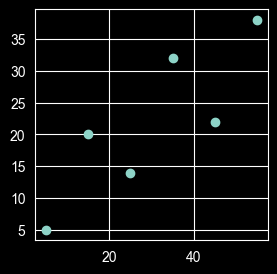

In [6]:
# Визуализируем данные
fig, ax = plt.subplots(figsize=(3, 3))
ax.scatter(x, y)
plt.show()

In [7]:
# Создадим модель линейной регрессии
# (from sklearn.linear_model import LinearRegression as LR)
model = LR()

# С помощью метода fit() применяем нашу модель к нашему набору данных,
# то есть обучаем модель.
model.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
# Обучив модель линейной регрессии, можно посмотреть на получившиеся коэффициенты
w0 = model.intercept_
w1 = model.coef_

In [9]:
# Так как у нас есть готовая модель,
# то теперь можно делать предсказания для новых объектов.
# В данном примере сделаем предсказание для тех же самых точек
y_pred = model.predict(x)

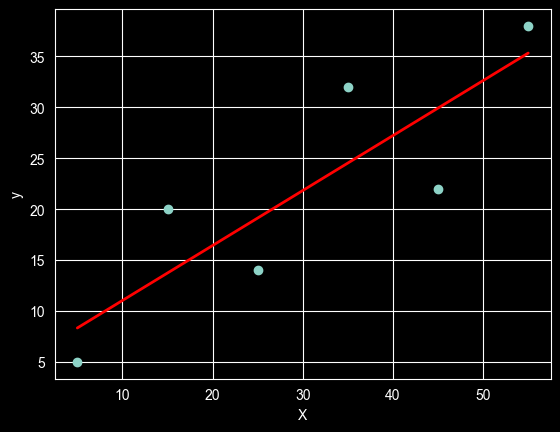

In [10]:
# Визуализируем наши объекты (синие точки) и линию регрессии,
# которую получили после обучения (красная линия)
plt.scatter(x, y)
plt.plot(x, y_pred, color='red', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [11]:
"""
Аналитическое решение линейной регрессии (Normal Equation).

Метод позволяет найти оптимальные коэффициенты модели
без использования градиентного спуска.

Формула:
    θ = (XᵀX)^(-1) Xᵀy

где:
    X — матрица признаков (с добавленным столбцом единиц для intercept),
    y — вектор целевых значений,
    θ — вектор параметров модели (intercept и коэффициенты).

Метод дает точное решение задачи минимизации MSE,
но вычислительно затратен при большом числе признаков.

Выводы:
    При x = 0 → y ≈ 5.63
    Каждый +1 по X увеличивает Y примерно на 0.54
    Это ровно та линия, которую ты видишь на графике.
"""
# Проверим полученные результаты аналитическими вычислениями
X_b = np.c_[np.ones((x.shape[0], 1)), x]
np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

array([5.63333333, 0.54      ])

In [12]:
"""
Оценка качества обучения модели
"""

# Расчет метрик
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("===== Оценка модели линейной регрессии =====\n")

print(f"Mean Absolute Error (MAE): {mae:.3f}")
print("→ В среднем модель ошибается примерно на", round(mae, 3), "единиц целевой переменной\n")

print(f"Mean Squared Error (MSE): {mse:.3f}")
print("→ Квадратичная ошибка усиливает влияние больших ошибок\n")

print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print("→ Средняя ошибка модели составляет примерно", round(rmse, 3), "в тех же единицах, что и целевая переменная\n")

print(f"R² score: {r2:.3f}")

if r2 > 0.9:
    print("→ Модель очень хорошо объясняет зависимость в данных")
elif r2 > 0.7:
    print("→ Модель хорошо объясняет данные")
elif r2 > 0.5:
    print("→ Модель объясняет данные умеренно")
else:
    print("→ Модель плохо описывает зависимость")

===== Оценка модели линейной регрессии =====

Mean Absolute Error (MAE): 5.467
→ В среднем модель ошибается примерно на 5.467 единиц целевой переменной

Mean Squared Error (MSE): 33.756
→ Квадратичная ошибка усиливает влияние больших ошибок

Root Mean Squared Error (RMSE): 5.810
→ Средняя ошибка модели составляет примерно 5.81 в тех же единицах, что и целевая переменная

R² score: 0.716
→ Модель хорошо объясняет данные
